Design and train a RNN using Tensorflow and Keras


In [11]:
#step-1
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"amritpratya","key":"4580f955dfce926805f83384856b0a8d"}'}

In [12]:
#step-2
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [17]:
#step-3
!kaggle datasets download -d jehanbhathena/weather-dataset
!unzip -q weather-dataset.zip -d /content/weather-data

Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/weather-dataset
License(s): CC0-1.0
 94% 552M/587M [00:06<00:00, 229MB/s]
100% 587M/587M [00:06<00:00, 91.2MB/s]


In [20]:
#step-4
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from google.colab import drive, files

In [31]:
#step-5
data_path = "/content/weather-data/dataset"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    data_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
    )

val_generator = datagen.flow_from_directory(
    data_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
    )

class_labels = list(train_generator.class_indices.keys())
print("Detected Classes:", class_labels)

Found 5493 images belonging to 11 classes.
Found 1369 images belonging to 11 classes.
Detected Classes: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [34]:
#step-6
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(11, activation='softmax')

])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [35]:
#step-7
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

print("\n Training the model...")
model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=val_generator,
    validation_steps=validation_steps
)


 Training the model...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 34s 157ms/step - accuracy: 0.3622 - loss: 1.9042 - val_accuracy: 0.6287 - val_loss: 1.1640
Epoch 2/10
  1/171 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6250 - loss: 1.2471

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


171/171 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.6250 - loss: 1.2471 - val_accuracy: 0.6220 - val_loss: 1.1638
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 21s 124ms/step - accuracy: 0.6080 - loss: 1.1772 - val_accuracy: 0.6994 - val_loss: 0.9675
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.6250 - loss: 1.1354 - val_accuracy: 0.6957 - val_loss: 0.9801
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 40s 145ms/step - accuracy: 0.6570 - loss: 1.0303 - val_accuracy: 0.7165 - val_loss: 0.9138
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8125 - loss: 0.7403 - val_accuracy: 0.7098 - val_loss: 0.9355
Epoch 7/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 42s 246ms/step - accuracy: 0.7191 - loss: 0.8308 - val_accuracy: 0.7001 - val_loss: 0.9367
Epoch 8/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7188 - loss: 0.6804 - val_accuracy: 0.6741 - val_loss: 1.0054
Epoch 9/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 59s 135ms/step - accuracy: 0.7474 - loss: 0.7678 - val_accurac


 Upload an image to classify:


Saving 2908.jpg to 2908 (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


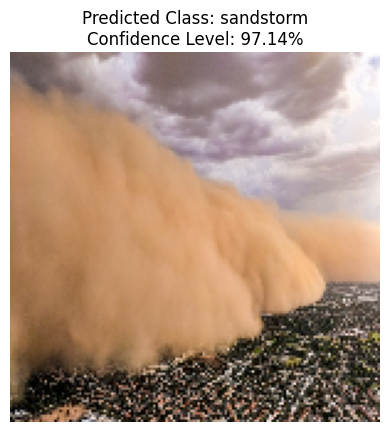

In [38]:
#step-8
print("\n Upload an image to classify:")
uploaded = files.upload()

for filename in uploaded.keys():
    img = load_img(filename, target_size=(150, 150))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0]
    predicted_class_index = np.argmax(prediction)
    predicted_class_label = class_labels[predicted_class_index]
    confidence = prediction[predicted_class_index] * 100

    plt.imshow(img)
    plt.title(f"Predicted Class: {predicted_class_label}\nConfidence Level: {confidence:.2f}%")
    plt.axis('off')
    plt.show()